## Oppsett og dataimport

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

# Konfigurer pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [18]:
# Last inn rådata
df_full = pd.read_excel("data/prosjekter.xlsx", sheet_name="Prosjekter_2014_2026pluss", skiprows=4)
print(f"Lastet inn {len(df_full)} prosjekter")
print(f"Kolonner: {list(df_full.columns)}")
df_full.head()


Lastet inn 101 prosjekter
Kolonner: ['virksomhet', 'status', 'navn', 'landsdel', 'aar_ferdig', 'stat_korrigert_2026', 'kommentar']


,virksomhet,status,navn,landsdel,aar_ferdig,stat_korrigert_2026,kommentar
0,SVV,Ferdig,E39 Hjartåberga,VEST,2014,1018.0,NaN
1,SVV,Ferdig,Rv. 70 Oppdølstranda,VEST,2014,1574.0,NaN
2,SVV,Ferdig,E18 Melleby–Momarken,ØST,2014,1746.0,NaN
3,SVV,Ferdig,Rv. 7 Sokna–Ørgenvika,ØST,2014,1296.0,NaN
4,SVV,Ferdig,Rv. 2 Kongsvinger–Slomarka,ØST,2014,1635.0,NaN


In [20]:
# Befolkningsdata for per-capita-normalisering
befolkning = pd.read_excel("data/prosjekter.xlsx", sheet_name="befolkning", skiprows=4)
befolkning

,landsdel,befolkning_2025,kilde
0,ØST,2870000,SSB tabell 06913 (Oslo + Akershus + Innlandet ...
1,VEST,1420000,SSB tabell 06913 (Rogaland + Vestland + Møre o...
2,MIDT,480000,SSB tabell 06913
3,NORD,480000,SSB tabell 06913 (Nordland + Troms + Finnmark)
4,SØR,320000,SSB tabell 06913 (Agder)


## Beregn total statlig finansiering per landsdel


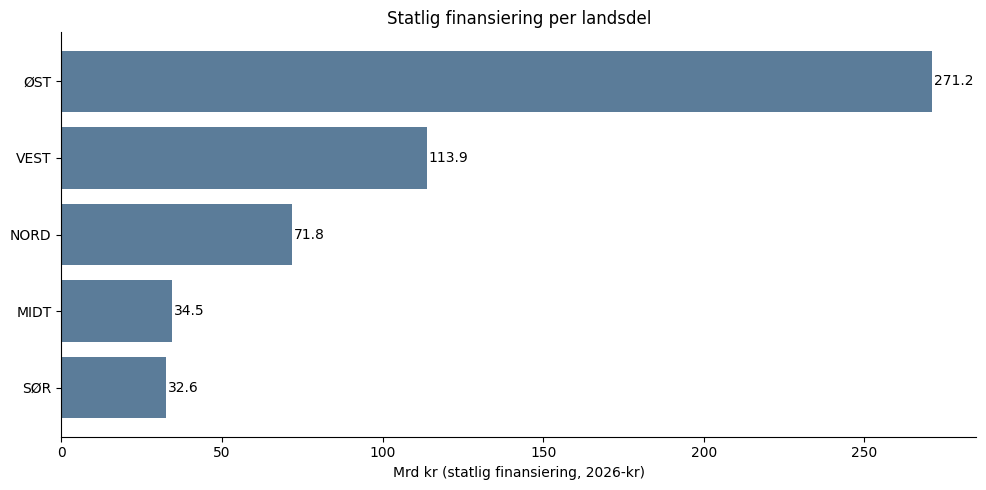

landsdel    mrd_kr
     SØR  32.56200
    MIDT  34.45250
    NORD  71.78700
    VEST 113.88800
     ØST 271.18075


In [21]:
df = df_full[df_full["landsdel"] != "HELE_LANDET"]
per_landsdel = (
    df.groupby("landsdel")["stat_korrigert_2026"]
    .sum()
    .sort_values(ascending=True)
    / 1000  # mill → mrd
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(per_landsdel.index, per_landsdel.values, color="#5B7C99")
ax.set_xlabel("Mrd kr (statlig finansiering, 2026-kr)")
ax.set_title("Statlig finansiering per landsdel")
for i, v in enumerate(per_landsdel.values):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT / "stat_per_landsdel.png", dpi=120, bbox_inches="tight")
plt.show()

print(per_landsdel.rename("mrd_kr").reset_index().to_string(index=False))


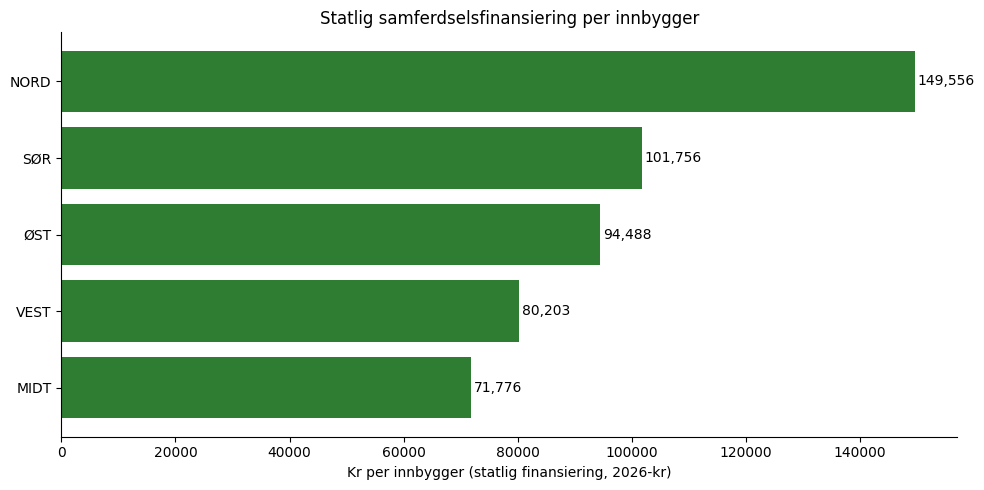

landsdel  stat_mrd  befolkning_2025  kr_per_innbygger
    MIDT  34.45250           480000             71776
    VEST 113.88800          1420000             80203
     ØST 271.18075          2870000             94488
     SØR  32.56200           320000            101756
    NORD  71.78700           480000            149556


In [23]:
# Per-capita-normalisering
pc = (
    per_landsdel.reset_index()
    .rename(columns={"stat_korrigert_2026": "stat_mrd"})
    .merge(befolkning[["landsdel", "befolkning_2025"]], on="landsdel")
)
pc["kr_per_innbygger"] = (pc["stat_mrd"] * 1_000_000_000 / pc["befolkning_2025"]).round(0).astype(int)
pc = pc.sort_values("kr_per_innbygger", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pc["landsdel"], pc["kr_per_innbygger"], color="#2E7D32")
ax.set_xlabel("Kr per innbygger (statlig finansiering, 2026-kr)")
ax.set_title("Statlig samferdselsfinansiering per innbygger")
for i, v in enumerate(pc["kr_per_innbygger"]):
    ax.text(v + 500, i, f"{v:,}", va="center")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT / "stat_per_innbygger.png", dpi=120, bbox_inches="tight")
plt.show()

print(pc[["landsdel", "stat_mrd", "befolkning_2025", "kr_per_innbygger"]].to_string(index=False))


### Periodisert

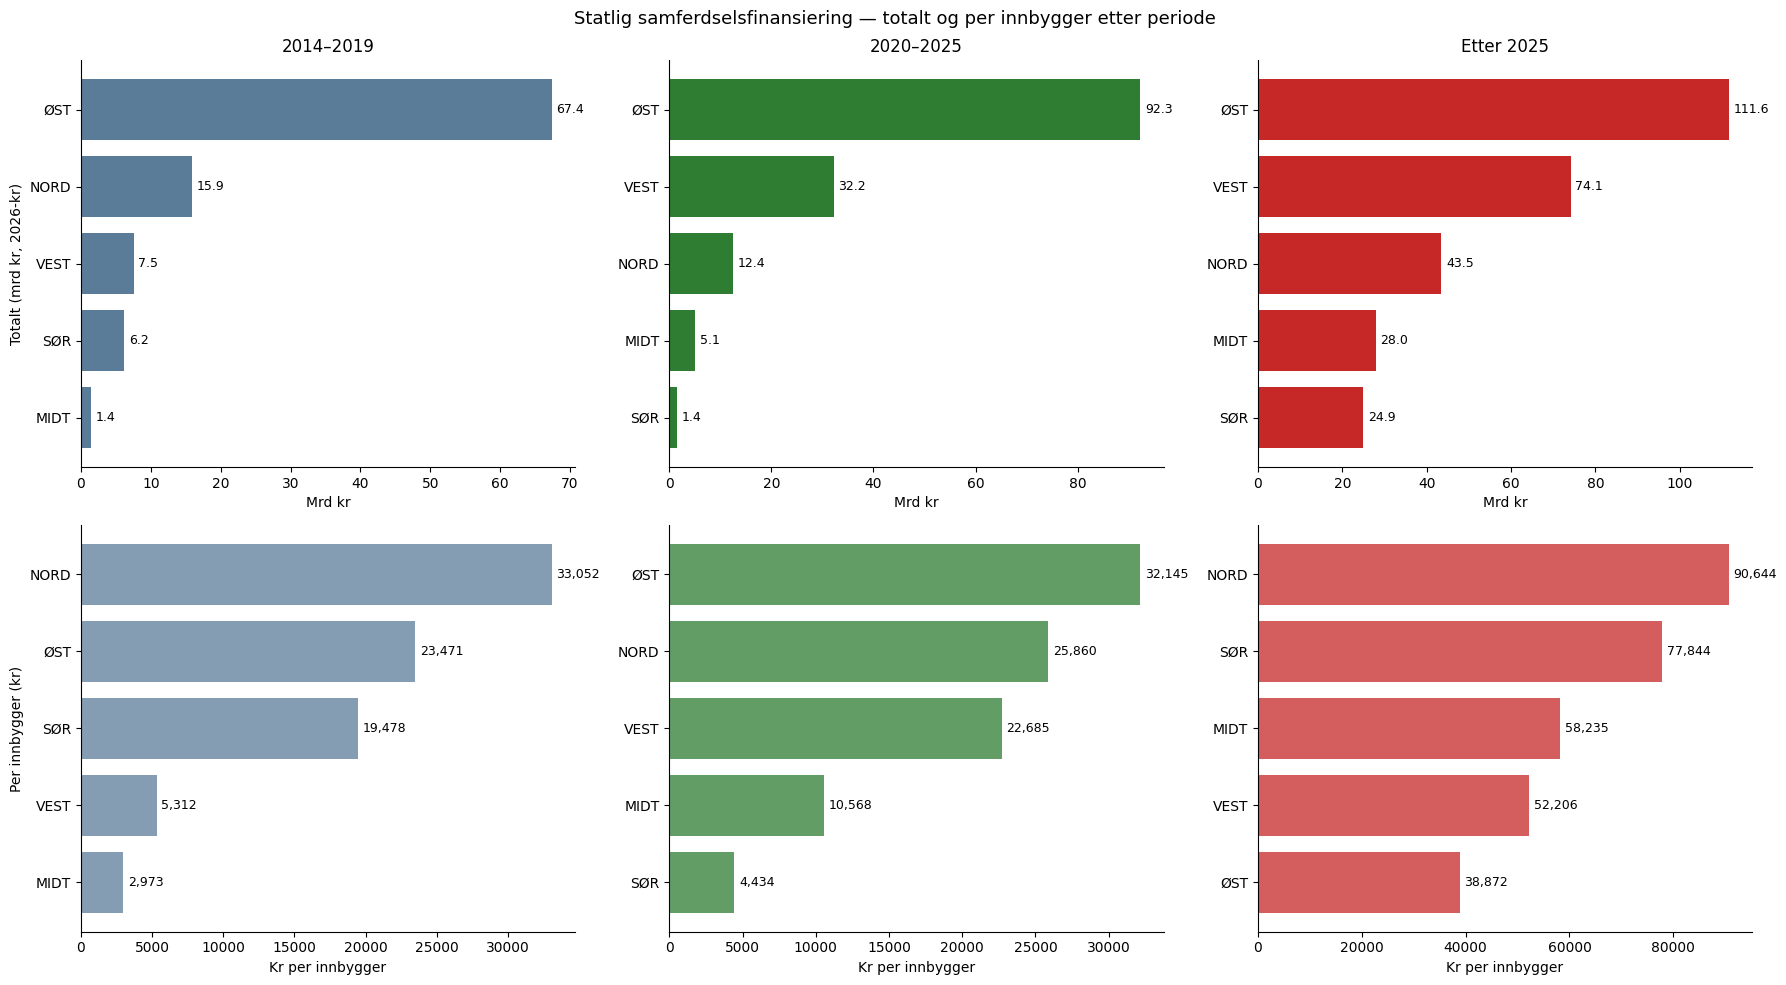

In [25]:
def per_capita_periode(data):
    """Beregn totalt (mrd kr) og kr per innbygger per landsdel for et utvalg."""
    total = (
        data.groupby("landsdel")["stat_korrigert_2026"]
        .sum()
        .reset_index()
        .rename(columns={"stat_korrigert_2026": "stat_mrd"})
    )
    total["stat_mrd"] /= 1000
    merged = total.merge(befolkning[["landsdel", "befolkning_2025"]], on="landsdel")
    merged["kr_per_innbygger"] = (merged["stat_mrd"] * 1_000_000_000 / merged["befolkning_2025"]).round(0).astype(int)
    return merged

perioder = [
    ("2014–2019", df[df["aar_ferdig"] <= 2019]),
    ("2020–2025", df[(df["aar_ferdig"] >= 2020) & (df["aar_ferdig"] <= 2025)]),
    ("Etter 2025", df[df["aar_ferdig"] >= 2026]),
]

colors = ["#5B7C99", "#2E7D32", "#C62828"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (etikett, utvalg), color in zip(range(3), perioder, colors):
    pc_p = per_capita_periode(utvalg)

    # Rad 0: totalt mrd kr
    pc_tot = pc_p.sort_values("stat_mrd", ascending=True)
    axes[0, col].barh(pc_tot["landsdel"], pc_tot["stat_mrd"], color=color)
    axes[0, col].set_xlabel("Mrd kr")
    axes[0, col].set_title(etikett)
    for i, v in enumerate(pc_tot["stat_mrd"]):
        axes[0, col].text(v + max(pc_tot["stat_mrd"]) * 0.01, i, f"{v:.1f}", va="center", fontsize=9)
    axes[0, col].spines["top"].set_visible(False)
    axes[0, col].spines["right"].set_visible(False)

    # Rad 1: kr per innbygger
    pc_pi = pc_p.sort_values("kr_per_innbygger", ascending=True)
    axes[1, col].barh(pc_pi["landsdel"], pc_pi["kr_per_innbygger"], color=color, alpha=0.75)
    axes[1, col].set_xlabel("Kr per innbygger")
    for i, v in enumerate(pc_pi["kr_per_innbygger"]):
        axes[1, col].text(v + max(pc_pi["kr_per_innbygger"]) * 0.01, i, f"{v:,}", va="center", fontsize=9)
    axes[1, col].spines["top"].set_visible(False)
    axes[1, col].spines["right"].set_visible(False)

axes[0, 0].set_ylabel("Totalt (mrd kr, 2026-kr)")
axes[1, 0].set_ylabel("Per innbygger (kr)")

fig.suptitle("Statlig samferdselsfinansiering — totalt og per innbygger etter periode", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT / "stat_perioder.png", dpi=120, bbox_inches="tight")
plt.show()
